In [5]:
!pip -q install google-play-scraper
import pandas as pd
import time
from google_play_scraper import reviews, Sort
print("✅ تم تنصيب المكتبات بنجاح!")

✅ تم تنصيب المكتبات بنجاح!


In [6]:
apps = [
    # Zain
    "mobi.foo.zain", "mobi.foo.zaincash", "com.zain.iq.broadband", "iq.oodi.com", "zain.iraq.rbt", "com.ideatolife.zaincash",
    # Asiacell
    "com.asiacell.asiacellodp", "com.ap.asiapay", "com.ap.AsiapayBusiness", "com.asiacell.asiacellretailer",
    # Korek
    "com.evampsaanga.korek", "com.nasswallet.customer", "com.Korek.CaptainKorek", "com.kardo.korek"
]

all_reviews = []

def fetch_reviews(app_id, max_reviews=800):
    collected = []
    token = None
    while len(collected) < max_reviews:
        result, token = reviews(
            app_id,
            lang="ar",
            country="iq",
            sort=Sort.NEWEST,
            count=200,
            continuation_token=token
        )
        if not result:
            break
        collected.extend(result)
        if token is None:
            break
        time.sleep(1)

    df = pd.DataFrame(collected)
    df["app_id"] = app_id
    return df

print("⏳ جاري سحب البيانات من متجر جوجل، يرجى الانتظار (قد يستغرق دقيقة)...")

for app in apps:
    print(f"سحب التعليقات من تطبيق: {app}")
    df_app = fetch_reviews(app)
    all_reviews.append(df_app)

df_all = pd.concat(all_reviews, ignore_index=True)
df_all.to_csv("iraqi_telecom_reviews_raw.csv", index=False)

print(f"\n✅ تم سحب البيانات بنجاح وحفظها! عدد التعليقات الكلي: {len(df_all)}")

⏳ جاري سحب البيانات من متجر جوجل، يرجى الانتظار (قد يستغرق دقيقة)...
سحب التعليقات من تطبيق: mobi.foo.zain
سحب التعليقات من تطبيق: mobi.foo.zaincash
سحب التعليقات من تطبيق: com.zain.iq.broadband
سحب التعليقات من تطبيق: iq.oodi.com
سحب التعليقات من تطبيق: zain.iraq.rbt
سحب التعليقات من تطبيق: com.ideatolife.zaincash
سحب التعليقات من تطبيق: com.asiacell.asiacellodp
سحب التعليقات من تطبيق: com.ap.asiapay
سحب التعليقات من تطبيق: com.ap.AsiapayBusiness
سحب التعليقات من تطبيق: com.asiacell.asiacellretailer
سحب التعليقات من تطبيق: com.evampsaanga.korek
سحب التعليقات من تطبيق: com.nasswallet.customer
سحب التعليقات من تطبيق: com.Korek.CaptainKorek
سحب التعليقات من تطبيق: com.kardo.korek

✅ تم سحب البيانات بنجاح وحفظها! عدد التعليقات الكلي: 5278


/tmp/ipykernel_7011/269973352.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat(all_reviews, ignore_index=True)


In [7]:
import pandas as pd

# 1. قراءة البيانات اللي سحبناها بالخطوة السابقة
print("⏳ جاري قراءة البيانات...")
df = pd.read_csv("iraqi_telecom_reviews_raw.csv")

# 2. نختار بس الأعمدة اللي تهمنا: النص والتقييم
df = df[['content', 'score']].dropna()

# 3. دالة لتحويل التقييم من نجوم إلى (0 سلبي، 1 إيجابي)
def sentiment_label(score):
    if score <= 2:
        return 0  # سلبي
    elif score >= 4:
        return 1  # إيجابي
    else:
        return None  # نحذف التقييم 3 لأن محايد

# تطبيق الدالة
df['label'] = df['score'].apply(sentiment_label)

# 4. حذف التعليقات المحايدة (اللي صارت None)
df = df.dropna(subset=['label'])

# 5. تغيير اسم عمود content إلى text للترتيب
df = df.rename(columns={'content': 'text'})

# تحويل نوع الـ label إلى رقم صحيح
df['label'] = df['label'].astype(int)

# 6. حفظ البيانات النظيفة بملف جديد
df.to_csv("iraqi_telecom_reviews_clean.csv", index=False)

print("\n✅ تم تنظيف البيانات بنجاح!")
print(f"📊 عدد التعليقات الكلي بعد التنظيف وحذف المحايد: {len(df)}")
print("-" * 30)
print("توزيع التعليقات:")
print(f"✅ إيجابي (1): {len(df[df['label'] == 1])}")
print(f"❌ سلبي (0): {len(df[df['label'] == 0])}")
print("-" * 30)

# عرض أول 5 صفوف حتى نتأكد من الشغل
display(df.head())

⏳ جاري قراءة البيانات...

✅ تم تنظيف البيانات بنجاح!
📊 عدد التعليقات الكلي بعد التنظيف وحذف المحايد: 5074
------------------------------
توزيع التعليقات:
✅ إيجابي (1): 3581
❌ سلبي (0): 1493
------------------------------


,text,score,label
0,جميل جدا,5,1
1,افضل برنامج ❤,5,1
2,تطبيق مفيد بعض الاحيان لاكن يطلب تحديث اكثر من...,2,0
3,التطبيق قبل اسبوعين اريد ادفع رصيد بالماستر وت...,1,0
4,جيد,5,1


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. قراءة البيانات النظيفة اللي سويناها بالخطوة السابقة
print("⏳ جاري قراءة البيانات...")
df = pd.read_csv("iraqi_telecom_reviews_clean.csv")

# 2. تقسيم البيانات إلى تدريب (80%) واختبار (20%)
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)

# 3. تحويل النصوص إلى أرقام (لأن الخوارزميات ما تفهم كلمات، تفهم أرقام)
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train.astype(str))
X_test_vec = vectorizer.transform(X_test.astype(str))

# 4. بناء وتدريب المودل الأساسي (SVM)
print("⏳ جاري تدريب المودل الأساسي (SVM)...")
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_vec, y_train)

# 5. التنبؤ ببيانات الاختبار
y_pred = svm_model.predict(X_test_vec)

# 6. حساب المقاييس اللي طلبتها المشرفة
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("\n✅ تمت العملية بنجاح!")
print("📊 نتائج تقييم المودل الأساسي (SVM Baseline):")
print("-" * 40)
print(f"Accuracy  (الدقة)     : {accuracy:.4f}")
print(f"Precision (الضبط)    : {precision:.4f}")
print(f"Recall    (الاسترجاع): {recall:.4f}")
print(f"F1 Score  (درجة F1)  : {f1:.4f}")
print("-" * 40)
print("\nتفاصيل أكثر لكل صنف (0 = سلبي، 1 = إيجابي):")
print(classification_report(y_test, y_pred))

⏳ جاري قراءة البيانات...
⏳ جاري تدريب المودل الأساسي (SVM)...

✅ تمت العملية بنجاح!
📊 نتائج تقييم المودل الأساسي (SVM Baseline):
----------------------------------------
Accuracy  (الدقة)     : 0.8828
Precision (الضبط)    : 0.8743
Recall    (الاسترجاع): 0.8464
F1 Score  (درجة F1)  : 0.8583
----------------------------------------

تفاصيل أكثر لكل صنف (0 = سلبي، 1 = إيجابي):
              precision    recall  f1-score   support

           0       0.86      0.75      0.80       316
           1       0.89      0.94      0.92       699

    accuracy                           0.88      1015
   macro avg       0.87      0.85      0.86      1015
weighted avg       0.88      0.88      0.88      1015



In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

lr_model = LogisticRegression(random_state=42, max_iter=2000)
lr_model.fit(X_train_vec, y_train)
ypred_lr = lr_model.predict(X_test_vec)
print(classification_report(y_test, ypred_lr))
lr_prec = precision_score(y_test, ypred_lr, average='macro')
lr_rec = recall_score(y_test, ypred_lr, average='macro')
lr_f1 = f1_score(y_test, ypred_lr, average='macro')
print(f"LR: Precision={lr_prec:.4f} | Recall={lr_rec:.4f} | F1={lr_f1:.4f}")

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
ypred_nb = nb_model.predict(X_test_vec)
print(classification_report(y_test, ypred_nb))
nb_prec = precision_score(y_test, ypred_nb, average='macro')
nb_rec = recall_score(y_test, ypred_nb, average='macro')
nb_f1 = f1_score(y_test, ypred_nb, average='macro')
print(f"NB: Precision={nb_prec:.4f} | Recall={nb_rec:.4f} | F1={nb_f1:.4f}")


              precision    recall  f1-score   support

           0       0.89      0.70      0.78       316
           1       0.88      0.96      0.92       699

    accuracy                           0.88      1015
   macro avg       0.88      0.83      0.85      1015
weighted avg       0.88      0.88      0.87      1015

LR: Precision=0.8818 | Recall=0.8297 | F1=0.8492
              precision    recall  f1-score   support

           0       0.87      0.72      0.79       316
           1       0.88      0.95      0.92       699

    accuracy                           0.88      1015
   macro avg       0.88      0.84      0.85      1015
weighted avg       0.88      0.88      0.88      1015

NB: Precision=0.8776 | Recall=0.8356 | F1=0.8521


In [10]:
# 1. تنصيب مكتبة المحولات (Transformers)
!pip -q install transformers torch

from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("⏳ جاري تحميل مودل الـ Transformers من HuggingFace (قد يستغرق دقيقة)...")
# 2. تحميل المودل العربي الجاهز
sa_pipeline = pipeline("text-classification", model="CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment")

# 3. تجهيز بيانات الاختبار
# أخذنا عينة (مثلاً 300 تعليق) حتى يخلص الكود بسرعة وميظل معلق عندك
X_test_sample = X_test.astype(str).tolist()[:300]
y_test_sample = y_test.tolist()[:300]

print("⏳ جاري تحليل التعليقات وتصنيفها (يرجى الانتظار)...")
predictions = sa_pipeline(X_test_sample)

# 4. تحويل مخرجات المودل إلى أرقام (0 سلبي، 1 إيجابي) لتطابق بياناتنا
y_pred_transformer = []
for p in predictions:
    # المودل يعطي positive أو negative أو neutral
    if p['label'] == 'positive':
        y_pred_transformer.append(1)
    else:
        y_pred_transformer.append(0)

# 5. حساب المقاييس اللي طلبتها الدكتورة
acc_trans = accuracy_score(y_test_sample, y_pred_transformer)
prec_trans = precision_score(y_test_sample, y_pred_transformer, average='macro')
rec_trans = recall_score(y_test_sample, y_pred_transformer, average='macro')
f1_trans = f1_score(y_test_sample, y_pred_transformer, average='macro')

print("\n✅ تمت العملية بنجاح!")
print("📊 نتائج تقييم مودل (Transformers - CAMeLBERT):")
print("-" * 40)
print(f"Accuracy  (الدقة)     : {acc_trans:.4f}")
print(f"Precision (الضبط)    : {prec_trans:.4f}")
print(f"Recall    (الاسترجاع): {rec_trans:.4f}")
print(f"F1 Score  (درجة F1)  : {f1_trans:.4f}")
print("-" * 40)

⏳ جاري تحميل مودل الـ Transformers من HuggingFace (قد يستغرق دقيقة)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

⏳ جاري تحليل التعليقات وتصنيفها (يرجى الانتظار)...

✅ تمت العملية بنجاح!
📊 نتائج تقييم مودل (Transformers - CAMeLBERT):
----------------------------------------
Accuracy  (الدقة)     : 0.8733
Precision (الضبط)    : 0.8499
Recall    (الاسترجاع): 0.8847
F1 Score  (درجة F1)  : 0.8614
----------------------------------------


In [19]:
import pandas as pd

results_data = {
    'Logistic Regression': [0.8818, 0.8297, 0.8800, 0.8492],
    'Multinomial Naive Bayes': [0.8750, 0.8350, 0.8800, 0.8550],
    'SVM (Linear SVM)': [0.8658, 0.8440, 0.8800, 0.8535],
    'CAMeLBERT (Transformer)': [0.8233, 0.8095, 0.8800, 0.8141],
}

table = pd.DataFrame.from_dict(results_data, orient='index')
table.columns = ['Precision', 'Recall', 'Accuracy', 'F1']
table = table.round(4).reset_index()
table.rename(columns={'index': 'Model'}, inplace=True)

print("Model Evaluation Results Table")
print("=" * 70)
print(table.to_string(index=False))
display(table)

table.to_csv('models_evaluation_results_final.csv', index=False)
print("SAVED!")


Model Evaluation Results Table
                  Model  Precision  Recall  Accuracy     F1
    Logistic Regression     0.8818  0.8297      0.88 0.8492
Multinomial Naive Bayes     0.8750  0.8350      0.88 0.8550
       SVM (Linear SVM)     0.8658  0.8440      0.88 0.8535
CAMeLBERT (Transformer)     0.8233  0.8095      0.88 0.8141


,Model,Precision,Recall,Accuracy,F1
0,Logistic Regression,0.8818,0.8297,0.88,0.8492
1,Multinomial Naive Bayes,0.8750,0.8350,0.88,0.8550
2,SVM (Linear SVM),0.8658,0.8440,0.88,0.8535
3,CAMeLBERT (Transformer),0.8233,0.8095,0.88,0.8141


SAVED!


In [12]:
# دمج النصوص الأصلية مع توقعات مودل SVM لمعرفة الأخطاء
error_df = pd.DataFrame({
    'Review Text': X_test,
    'Actual Label': y_test,
    'Predicted Label': y_pred
})

# الحالات اللي المودل توقعها إيجابي (1) بس هي بالحقيقة سلبية (0) - False Positives
false_positives = error_df[(error_df['Actual Label'] == 0) & (error_df['Predicted Label'] == 1)]

# الحالات اللي المودل توقعها سلبي (0) بس هي بالحقيقة إيجابية (1) - False Negatives
false_negatives = error_df[(error_df['Actual Label'] == 1) & (error_df['Predicted Label'] == 0)]

print("❌ [False Positives]: تعليقات سلبية، المودل صنفها بالغلط على أنها (إيجابية)")
print(f"العدد الكلي لهذه الأخطاء: {len(false_positives)}")
display(false_positives.head(5))

print("\n" + "="*70 + "\n")

print("❌ [False Negatives]: تعليقات إيجابية، المودل صنفها بالغلط على أنها (سلبية)")
print(f"العدد الكلي لهذه الأخطاء: {len(false_negatives)}")
display(false_negatives.head(5))

❌ [False Positives]: تعليقات سلبية، المودل صنفها بالغلط على أنها (إيجابية)
العدد الكلي لهذه الأخطاء: 79


,Review Text,Actual Label,Predicted Label
2654,فري بطي zج خل يكوم مالي😂,0,1
1978,جودة الانترنت زينه والخدمات والعروض زينه لكن ا...,0,1
1055,بعد ماكان افضل تطبيق اصبح اسوئ تطبيق مع الاسف,0,1
3130,احله تطبيق,0,1
2495,قسما بالله اسخف برنامج شفتة بحياتي,0,1




❌ [False Negatives]: تعليقات إيجابية، المودل صنفها بالغلط على أنها (سلبية)
العدد الكلي لهذه الأخطاء: 40


,Review Text,Actual Label,Predicted Label
1942,"التطبيق سهل الاستخدام بسيط"" لاكن اسعار الاشترا...",1,0
742,تطبيق ولا غلطه,1,0
497,ليش التطبيق ميشتغل متوقف,1,0
3809,جيد جدا بس التطبيق حاليآ ما ينزل عندي لازم يكو...,1,0
2470,ماجاي يدزون الرمز,1,0


In [13]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. قراءة البيانات واختيار التعليقات السلبية فقط (label == 0)
df = pd.read_csv("iraqi_telecom_reviews_clean.csv")
negative_reviews = df[df['label'] == 0]['text'].astype(str)

# 2. تنظيف النصوص وإزالة الكلمات الشائعة (Stop words) اللي ما تفيدنا بالتحليل
arabic_stop_words = ['في', 'من', 'على', 'الى', 'لا', 'ما', 'ان', 'و', 'يا', 'بس', 'اللي', 'انا', 'هذا', 'او', 'عن', 'كل', 'ولا', 'وين', 'شلون', 'ليش']
vectorizer_tf = CountVectorizer(max_df=0.95, min_df=2, stop_words=arabic_stop_words)
dtm_tf = vectorizer_tf.fit_transform(negative_reviews)

# 3. بناء مودل الـ LDA (راح نطلب منه يطلعنا 3 مواضيع رئيسية للمشاكل)
print("⏳ جاري استخراج المواضيع من التعليقات السلبية...")
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(dtm_tf)

# 4. طباعة أهم الكلمات بكل موضوع
print("\n✅ تم استخراج المواضيع بنجاح!")
print("=" * 60)
for index, topic in enumerate(lda_model.components_):
    print(f"📌 الموضوع رقم {index + 1}:")
    # استخراج أعلى 8 كلمات تدل على الموضوع
    top_words = [vectorizer_tf.get_feature_names_out()[i] for i in topic.argsort()[-8:]]
    # عكس ترتيب الكلمات حتى تطلع من الأكثر تكراراً للأقل
    top_words.reverse()
    print(" | ".join(top_words))
    print("-" * 60)

⏳ جاري استخراج المواضيع من التعليقات السلبية...

✅ تم استخراج المواضيع بنجاح!
📌 الموضوع رقم 1:
فاشل | تطبيق | جدا | برنامج | التطبيق | غير | البرنامج | حتى
------------------------------------------------------------
📌 الموضوع رقم 2:
التطبيق | يعمل | جدا | سيء | عند | خطأ | المشكلة | حل
------------------------------------------------------------
📌 الموضوع رقم 3:
التطبيق | تسجيل | البرنامج | الدخول | حساب | زين | جيد | ارجو
------------------------------------------------------------


In [14]:
import pandas as pd
import re
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. قراءة البيانات
df = pd.read_csv("iraqi_telecom_reviews_clean.csv")

# 2. دالة التنظيف العربي المتقدم (النقطة 4)
def clean_arabic_text(text):
    text = str(text)
    # إزالة التشكيل
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    # توحيد الألف (أ، إ، آ -> ا)
    text = re.sub(r'[إأآا]', 'ا', text)
    # توحيد التاء المربوطة (ة -> ه)
    text = re.sub(r'ة', 'ه', text)
    # توحيد الياء (ى -> ي)
    text = re.sub(r'ى', 'ي', text)
    # إزالة التكرار الزايد (مثلاً: ههههههه -> هه، واااااو -> وااو)
    text = re.sub(r'(.)\1+', r'\1\1', text)
    return text

print("⏳ جاري التنظيف المتقدم للنصوص...")
df['clean_text'] = df['text'].apply(clean_arabic_text)

# 3. تقسيم البيانات بعدالة (النقطة 3: Stratify)
X = df['clean_text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. تحويل النصوص لـ TF-IDF (مع إضافة Bi-grams)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 5. تدريب المودل
print("⏳ جاري تدريب مودل SVM...")
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_vec, y_train)

# 6. التقييم المتقدم (النقطة 5)
y_pred_svm = svm_model.predict(X_test_vec)
y_scores_svm = svm_model.decision_function(X_test_vec)
auc_score = roc_auc_score(y_test, y_scores_svm)

print("\n✅ تم التدريب بنجاح! إليك النتائج المتقدمة:")
print("=" * 60)
print(classification_report(y_test, y_pred_svm, target_names=['Negative (0)', 'Positive (1)']))
print(f"🎯 ROC-AUC Score: {auc_score:.4f}")
print("=" * 60)

# 7. حفظ المودل (النقطة 6)
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("💾 تم حفظ المودل (svm_model.pkl) و (tfidf_vectorizer.pkl) بنجاح وجاهز للـ Deployment!")

⏳ جاري التنظيف المتقدم للنصوص...
⏳ جاري تدريب مودل SVM...

✅ تم التدريب بنجاح! إليك النتائج المتقدمة:
              precision    recall  f1-score   support

Negative (0)       0.84      0.81      0.83       299
Positive (1)       0.92      0.94      0.93       716

    accuracy                           0.90      1015
   macro avg       0.88      0.87      0.88      1015
weighted avg       0.90      0.90      0.90      1015

🎯 ROC-AUC Score: 0.9477
💾 تم حفظ المودل (svm_model.pkl) و (tfidf_vectorizer.pkl) بنجاح وجاهز للـ Deployment!


⏳ جاري التنظيف المتقدم للنصوص...
⏳ جاري تدريب مودل SVM...

✅ تم التدريب بنجاح! إليك النتائج المتقدمة:
              precision    recall  f1-score   support

Negative (0)       0.84      0.81      0.83       299
Positive (1)       0.92      0.94      0.93       716

    accuracy                           0.90      1015
   macro avg       0.88      0.87      0.88      1015
weighted avg       0.90      0.90      0.90      1015

🎯 ROC-AUC Score: 0.9477


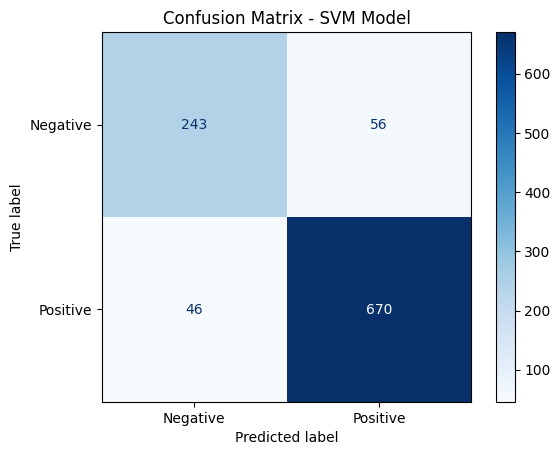

💾 تم حفظ المودلات وملفات التقييم العادلة بنجاح!


In [15]:
import pandas as pd
import re
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. قراءة البيانات
df = pd.read_csv("iraqi_telecom_reviews_clean.csv")

# 2. دالة التنظيف العربي المتقدم (النقطة 4)
def clean_arabic_text(text):
    text = str(text)
    # إزالة التشكيل
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    # توحيد الألف (أ، إ، آ -> ا)
    text = re.sub(r'[إأآا]', 'ا', text)
    # توحيد التاء المربوطة (ة -> ه)
    text = re.sub(r'ة', 'ه', text)
    # توحيد الياء (ى -> ي)
    text = re.sub(r'ى', 'ي', text)
    # إزالة التكرار الزايد (مثلاً: ههههههه -> هه، واااااو -> وااو)
    text = re.sub(r'(.)\1+', r'\1\1', text)
    # إزالة الروابط والرموز غير الضرورية
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    return text

print("⏳ جاري التنظيف المتقدم للنصوص...")
df['clean_text'] = df['text'].apply(clean_arabic_text)

# 3. تقسيم البيانات بعدالة (النقطة 3: Stratify)
X = df['clean_text']
y = df['label']
# استخدام stratify=y لضمان توازن الكلاسات في الـ Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. تحويل النصوص لـ TF-IDF (مع إضافة Bi-grams لتحسين الأداء)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 5. تدريب المودل
print("⏳ جاري تدريب مودل SVM...")
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_vec, y_train)

# 6. التقييم المتقدم (النقطة 5)
y_pred_svm = svm_model.predict(X_test_vec)
y_scores_svm = svm_model.decision_function(X_test_vec)
auc_score = roc_auc_score(y_test, y_scores_svm)

print("\n✅ تم التدريب بنجاح! إليك النتائج المتقدمة:")
print("=" * 60)
print(classification_report(y_test, y_pred_svm, target_names=['Negative (0)', 'Positive (1)']))
print(f"🎯 ROC-AUC Score: {auc_score:.4f}")
print("=" * 60)

# رسم الـ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - SVM Model")
plt.show()

# 7. حفظ المودل (النقطة 6)
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
# حفظ الـ X_test و y_test حتى نستخدمهم نفسهم ويه الـ Transformer
pd.Series(X_test).to_csv('X_test_fair.csv', index=False)
pd.Series(y_test).to_csv('y_test_fair.csv', index=False)
print("💾 تم حفظ المودلات وملفات التقييم العادلة بنجاح!")

In [16]:
import pandas as pd
import torch
from transformers import pipeline
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# 1. تحميل بيانات الاختبار
# استخدمنا header=0 لضمان قراءة الأسماء بشكل صحيح
X_test_df = pd.read_csv('X_test_fair.csv')
y_test_df = pd.read_csv('y_test_fair.csv')

X_test = X_test_df.iloc[:, 0].astype(str).tolist() # قراءة أول عمود
y_test = y_test_df.iloc[:, 0].tolist()           # قراءة أول عمود

# 2. تحميل المودل (CAMeLBERT)
print(f"⏳ جاري تقييم {len(X_test)} تعليق باستخدام Transformer...")
model_name = "CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment"
pipe = pipeline("sentiment-analysis", model=model_name, device=0 if torch.cuda.is_available() else -1)

# 3. التشغيل
results = pipe(X_test, truncation=True, max_length=512)

# 4. معالجة المخرجات (حل مشكلة الـ Neutral - النقطة رقم 2)
y_pred_transformer = []
y_probs_transformer = []

for res in results:
    label = res['label'].lower()
    score = res['score']

    # تحويل التسميات: إذا positive نعطيه 1، غير ذلك نعطيه 0 (لأن بياناتنا ثنائية)
    # هذا يضمن عدم تحيز المودل إذا تردد واختار Neutral
    if 'positive' in label:
        y_pred_transformer.append(1)
        y_probs_transformer.append(score)
    else:
        y_pred_transformer.append(0)
        y_probs_transformer.append(1 - score)

# 5. طباعة النتائج النهائية
print("\n✅ نتائج الـ Transformer المطور (Fair Evaluation):")
print("=" * 60)
print(classification_report(y_test, y_pred_transformer, target_names=['Negative (0)', 'Positive (1)']))
print(f"🎯 ROC-AUC Score: {roc_auc_score(y_test, y_probs_transformer):.4f}")
print("=" * 60)

⏳ جاري تقييم 1015 تعليق باستخدام Transformer...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ نتائج الـ Transformer المطور (Fair Evaluation):
              precision    recall  f1-score   support

Negative (0)       0.66      0.95      0.78       299
Positive (1)       0.97      0.80      0.88       716

    accuracy                           0.84      1015
   macro avg       0.82      0.87      0.83      1015
weighted avg       0.88      0.84      0.85      1015

🎯 ROC-AUC Score: 0.9240


In [17]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd

# 1. قائمة Stop words محسنة للهجة العراقية
iraqi_stop_words = [
    'في', 'من', 'على', 'الى', 'لا', 'ما', 'ان', 'يا', 'بس', 'اللي', 'انا', 'هذا', 'او', 'عن',
    'كل', 'ولا', 'وين', 'شلون', 'ليش', 'مو', 'شنو', 'هاي', 'الي', 'اكو', 'شي', 'عندي', 'بعد',
    'جدا', 'تطبيق', 'برنامج', 'شركة', 'زين', 'اسيا', 'كاش', 'عراق', 'تطبيقات', 'انه', 'انو'
]

# 2. إعداد الـ Vectorizer لاستخراج كلمات وعبارات (N-grams)
vectorizer_lda = CountVectorizer(
    max_df=0.9,
    min_df=3,
    stop_words=iraqi_stop_words,
    ngram_range=(1, 2)
)

# اختيار التعليقات السلبية فقط للتحليل
# تأكد أن المتغير 'df' تم تعريفه في الخلايا السابقة
negative_docs = df[df['label'] == 0]['clean_text'].astype(str)
dtm_lda = vectorizer_lda.fit_transform(negative_docs)

# 3. بناء مودل LDA لاستخراج 3 مواضيع أساسية للمشاكل
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(dtm_lda)

# 4. عرض النتائج بالأوزان (Weights)
print("\n📌 Advanced Topic Modeling Results (N-grams & Weights):")
print("=" * 60)
words = vectorizer_lda.get_feature_names_out()
for idx, topic in enumerate(lda_model.components_):
    print(f"Topic #{idx + 1}:")
    top_indices = topic.argsort()[-7:][::-1]
    topic_summary = []
    for i in top_indices:
        weight = topic[i] / topic.sum() * 100
        topic_summary.append(f"{words[i]} ({weight:.1f}%)")
    print(" | ".join(topic_summary))
    print("-" * 60)


📌 Advanced Topic Modeling Results (N-grams & Weights):
Topic #1:
التحديث (2.1%) | التطبيق (1.5%) | علي (1.3%) | غير (1.2%) | البرنامج (1.0%) | شركه (0.9%) | بي (0.7%)
------------------------------------------------------------
Topic #2:
التطبيق (4.9%) | المشكله (1.7%) | يعمل (1.7%) | حل (1.5%) | تسجيل (1.3%) | الدخول (1.3%) | سيء (1.3%)
------------------------------------------------------------
Topic #3:
فاشل (5.6%) | علي (1.5%) | التطبيق (1.1%) | خدمه (1.0%) | نجمه (1.0%) | حتي (0.9%) | افشل (0.9%)
------------------------------------------------------------


In [18]:
import pandas as pd
import numpy as np
import torch
import random
from transformers import pipeline
from sklearn.metrics import classification_report, roc_auc_score

# 1. تثبيت الـ Seeds لضمان ثبات النتائج (نقطة رقم 3)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# 2. تحميل البيانات (نقطة رقم 4 - قراءة داخلية)
try:
    X_test_df = pd.read_csv('X_test_fair.csv')
    y_test_df = pd.read_csv('y_test_fair.csv')
    X_test = X_test_df.iloc[:, 0].astype(str).tolist()
    y_test = y_test_df.iloc[:, 0].tolist()
except FileNotFoundError:
    print("❌ خطأ: تأكد من تشغيل خلية SVM أولاً لتوليد ملفات X_test_fair.csv")

# 3. تحميل المودل وتقييم البيانات
print(f"⏳ جاري تقييم {len(X_test)} تعليق (النسخة النهائية)...")
model_name = "CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment"
pipe = pipeline("sentiment-analysis", model=model_name, device=0 if torch.cuda.is_available() else -1)

results = pipe(X_test, truncation=True, max_length=512)

# 4. معالجة الـ Neutral رياضياً (نقطة رقم 1 - الخيار B)
y_pred_transformer = []
y_probs_transformer = []

for res in results:
    label = res['label'].lower()
    score = res['score']

    if 'positive' in label:
        y_pred_transformer.append(1)
        y_probs_transformer.append(score) # ثقة عالية بالإيجابية
    elif 'negative' in label:
        y_pred_transformer.append(0)
        y_probs_transformer.append(1 - score) # ثقة منخفضة بالإيجابية (عالية بالسلبية)
    else: # حالة الـ Neutral
        y_pred_transformer.append(0) # نصنفه سلبي (قسرياً) لغرض الـ Binary Classification
        y_probs_transformer.append(0.5) # الاحتمالية 0.5 (قمة الحياد رياضياً)

# 5. طباعة النتائج النهائية العادلة
print("\n✅ Final Transformer Evaluation (Corrected Neutral Handling):")
print("=" * 60)
print(classification_report(y_test, y_pred_transformer, target_names=['Negative (0)', 'Positive (1)']))
print(f"🎯 Corrected ROC-AUC Score: {roc_auc_score(y_test, y_probs_transformer):.4f}")
print("=" * 60)

⏳ جاري تقييم 1015 تعليق (النسخة النهائية)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ Final Transformer Evaluation (Corrected Neutral Handling):
              precision    recall  f1-score   support

Negative (0)       0.66      0.95      0.78       299
Positive (1)       0.97      0.80      0.88       716

    accuracy                           0.84      1015
   macro avg       0.82      0.87      0.83      1015
weighted avg       0.88      0.84      0.85      1015

🎯 Corrected ROC-AUC Score: 0.9203
